In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')

from attn_bench.plotting.utils import SEQ_LEN

REPS = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]   # repetition buckets

## Long Gutenberg: Data coverage
Long Gutenberg was built by taking the continuation of the sampled 8192-long Gutenberg snippets from their original books. Therefore, they are of different lengths. Sample range `[0, 8190)` is
always full; dotted lines mark multiples of `seq_len`.

In [ ]:
from attn_bench.plotting import model_registry
from attn_bench.plotting.long_inference import plot_coverage

# lengths.jsonl copied locally from the cluster
df = pd.DataFrame([json.loads(l) for l in model_registry.GUTENBERG_LONG_LENGTHS_PATH.open()])
BUCKETS = sorted(int(b) for b in df["bucket_rep"].unique())
print(f"{len(df):,} rows, {len(BUCKETS)} buckets: {BUCKETS}")

fig = plot_coverage(df, BUCKETS)
plt.show()

## Long Gutenberg: Position-wise loss x repetition bucket
One cell per repetition bucket, every model overlaid. Dotted line at 8190 = sample end.
Count panel below each cell shows the thinning sequence tail.

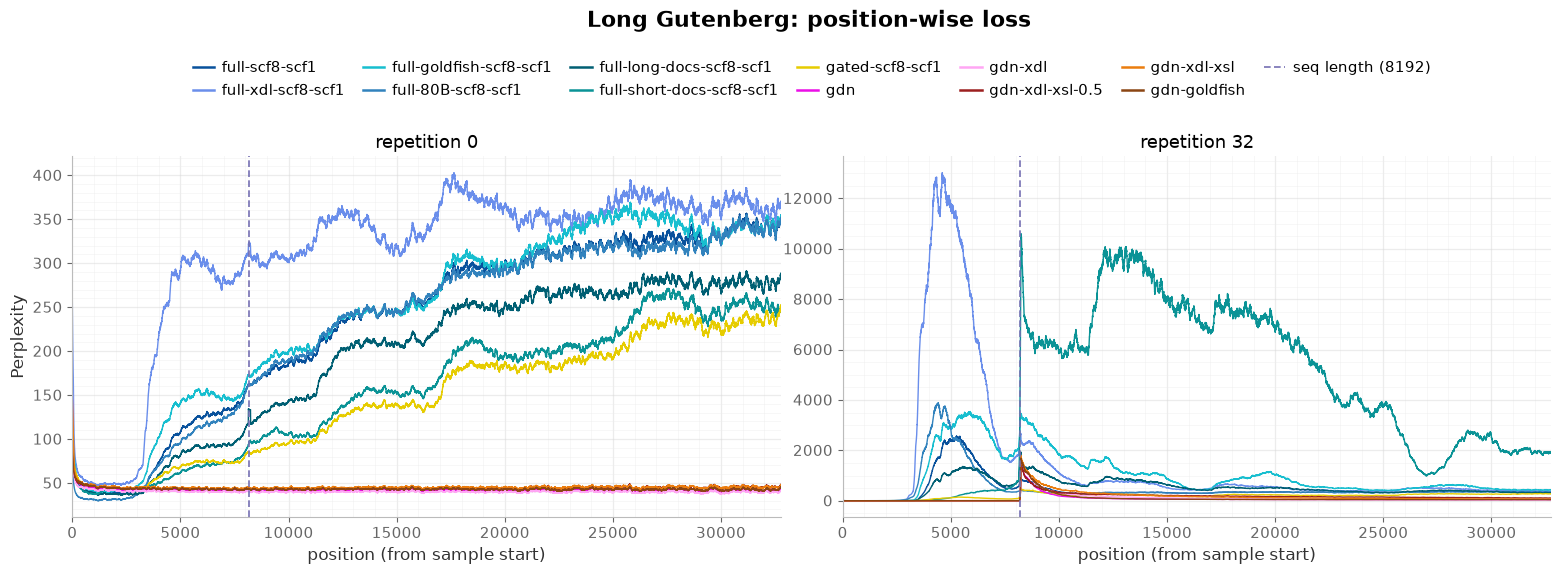

In [3]:
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_long_inference_nll_grid
from attn_bench.plotting.long_inference import plot_loss_panel

MODELS_TO_PLOT = [
    "full-scf8-scf1", "full-xdl-scf8-scf1", "full-goldfish-scf8-scf1", "full-80B-scf8-scf1",
    "full-long-docs-scf8-scf1", "full-short-docs-scf8-scf1",
    # "off-by-one-scf8-scf1", "learn-sink-scf8-scf1",
    "gated-scf8-scf1",
    "gdn", "gdn-xdl", "gdn-xdl-xsl-0.5", "gdn-xdl-xsl", "gdn-goldfish",
]
REPS_TO_PLOT = [0, 32]

nll_grid = load_long_inference_nll_grid(REPS_TO_PLOT, models=MODELS_TO_PLOT)

# sharey=False: a shared y-scale would compress the low-rep cells under the high-rep tail.
fig = plot_loss_panel(nll_grid, ncols=2, metric="ppl", show_random_baseline=False,
                      smooth_window=100, xmax=4 * SEQ_LEN,
                      show_std=False, show_count=False, sharey=False,
                      suptitle="Long Gutenberg: position-wise loss",
                      colors=model_registry.MODEL_COLORS,
                      vlines={"seq length": SEQ_LEN})
plt.show()

## Long FineWeb-Edu: seen vs unseen
Same models, on naturally-long FineWeb-Edu docs -- no rep buckets, seen vs unseen
partition instead.

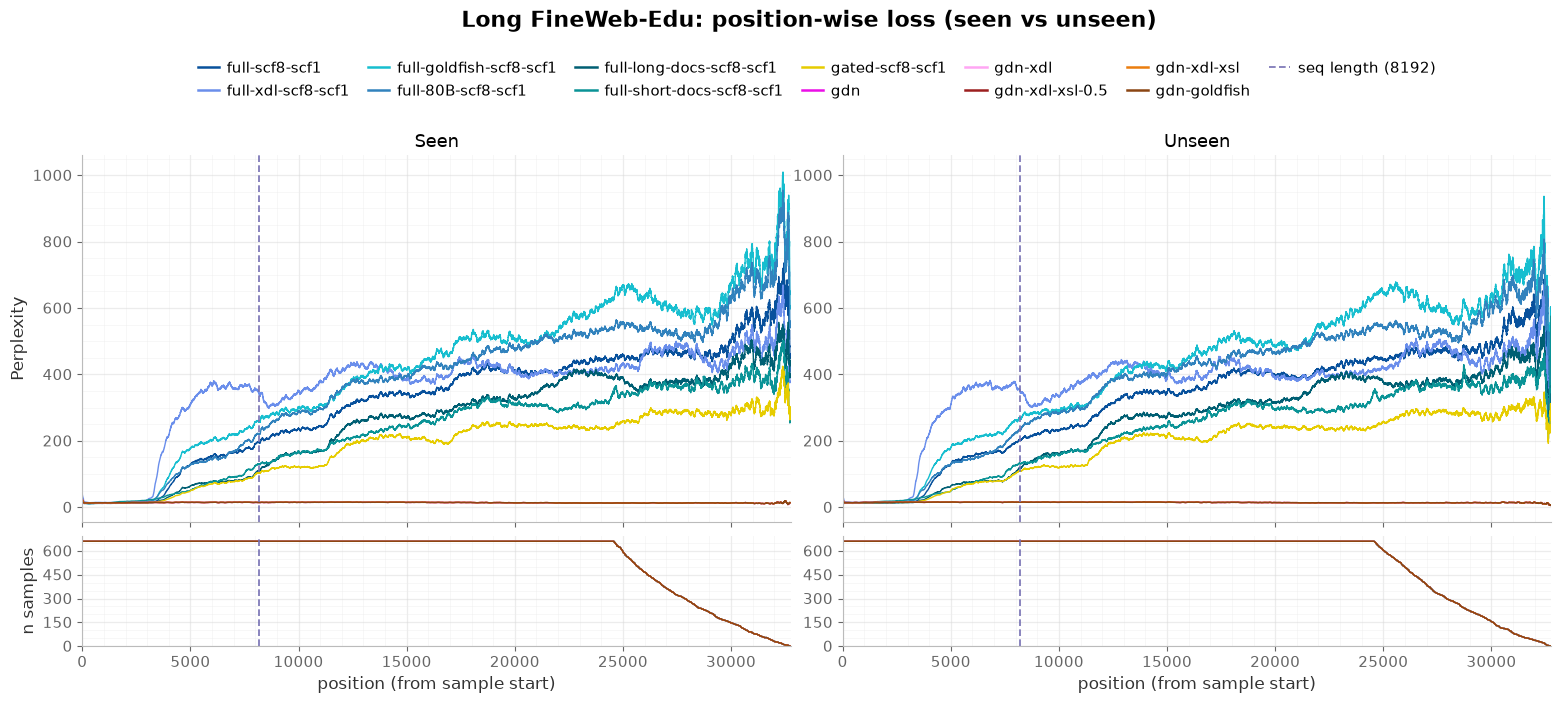

In [4]:
from attn_bench.plotting.data_loading import load_long_fineweb_inference_nll_grid

fineweb_nll_grid = load_long_fineweb_inference_nll_grid(models=MODELS_TO_PLOT)

fig = plot_loss_panel(fineweb_nll_grid, ncols=2, metric='ppl', smooth_window=100, xmax=4 * SEQ_LEN,
                      show_std=False, show_count=True, sharey=True, show_random_baseline=False,
                      colors=model_registry.MODEL_COLORS,
                      bucket_title_fn=str.capitalize,
                      suptitle="Long FineWeb-Edu: position-wise loss (seen vs unseen)",
                      vlines={"seq length": SEQ_LEN})
plt.show()

---
## Unseen FineWeb vs unseen Gutenberg (rep 0)
Isolates the data-domain effect from memorization.
One panel per model, FineWeb-unseen vs Gutenberg-unseen (rep 0) overlaid.

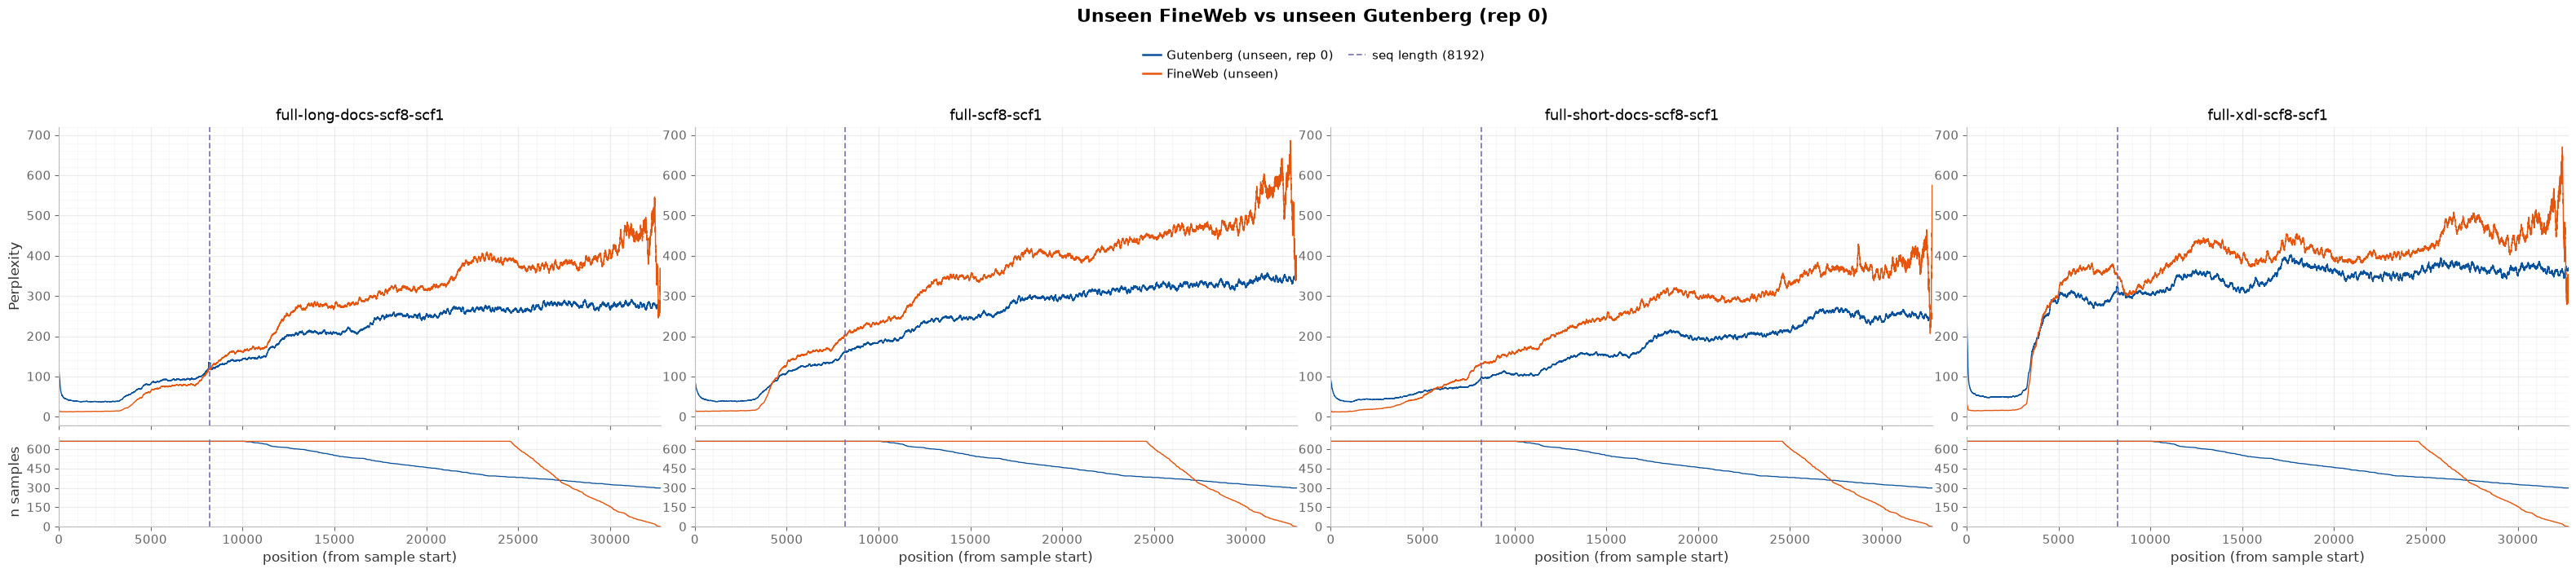

In [5]:
MODELS_TO_PLOT = [
    "full-scf8-scf1",
    "full-xdl-scf8-scf1",
    # "full-goldfish-scf8-scf1", "full-80B-scf8-scf1",
    "full-long-docs-scf8-scf1", "full-short-docs-scf8-scf1",
    # "off-by-one-scf8-scf1", "learn-sink-scf8-scf1",
    # "gated-scf8-scf1",
    # "gdn", "gdn-xdl", "gdn-xdl-xsl-0.5", "gdn-xdl-xsl", "gdn-goldfish",
]
# todo: rename to gutenberg
gutenberg_unseen = load_long_inference_nll_grid([0], models=MODELS_TO_PLOT)
fineweb_unseen = load_long_fineweb_inference_nll_grid(partitions=["unseen"], models=MODELS_TO_PLOT)

nll_by_corpus = {
    "Gutenberg (unseen, rep 0)": {m: d[0] for m, d in gutenberg_unseen.items()},
    "FineWeb (unseen)": {m: d["unseen"] for m, d in fineweb_unseen.items()},
}

fig = plot_loss_panel(nll_by_corpus, ncols=4, bucket_title_fn=lambda m: m,
                      smooth_window=100, xmax=4 * SEQ_LEN, show_count=True,
                      sharey=True,
                      colors={"Gutenberg (unseen, rep 0)": "#08519c", "FineWeb (unseen)": "#e6550d"},
                      suptitle="Unseen FineWeb vs unseen Gutenberg (rep 0)",
                      vlines={"seq length": SEQ_LEN}, metric="ppl")
plt.show()

---
## Seen FineWeb vs seen Gutenberg (rep 1)

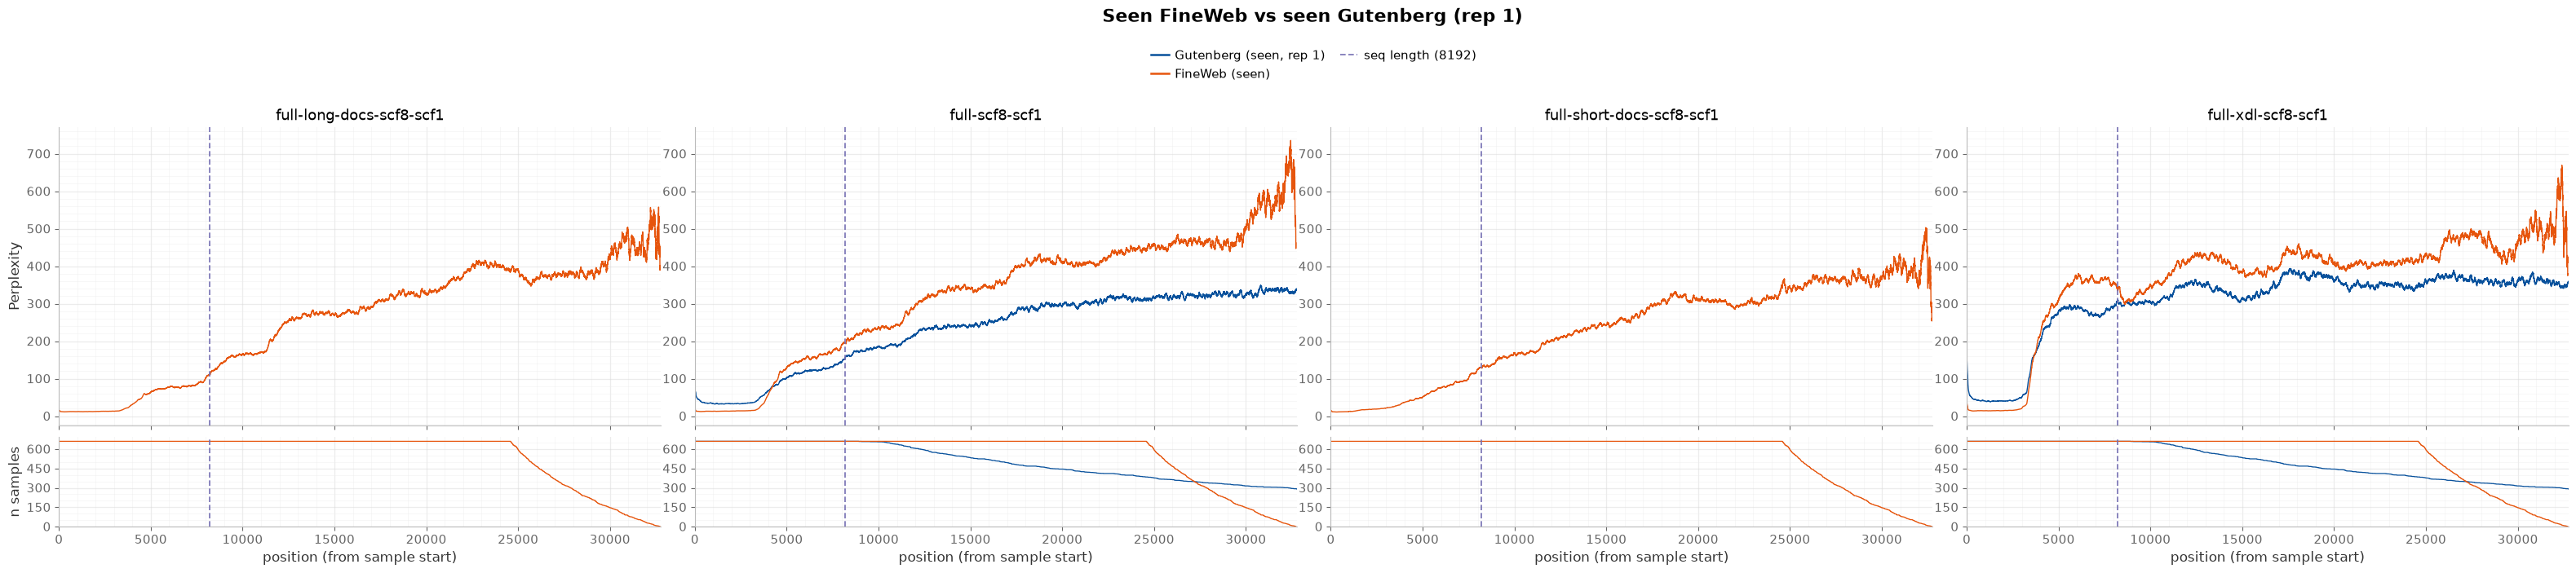

In [6]:
MODELS_TO_PLOT = [
    "full-scf8-scf1",
    "full-xdl-scf8-scf1",
    # "full-goldfish-scf8-scf1", "full-80B-scf8-scf1",
    "full-long-docs-scf8-scf1", "full-short-docs-scf8-scf1",
    # "off-by-one-scf8-scf1", "learn-sink-scf8-scf1",
    # "gated-scf8-scf1",
    # "gdn", "gdn-xdl", "gdn-xdl-xsl-0.5", "gdn-xdl-xsl", "gdn-goldfish",
]
# todo: rename to gutenberg
gutenberg_seen = load_long_inference_nll_grid([1], models=MODELS_TO_PLOT)
fineweb_seen = load_long_fineweb_inference_nll_grid(partitions=["seen"], models=MODELS_TO_PLOT)

nll_by_corpus = {
    "Gutenberg (seen, rep 1)": {m: d[1] for m, d in gutenberg_seen.items()},
    "FineWeb (seen)": {m: d["seen"] for m, d in fineweb_seen.items()},
}

fig = plot_loss_panel(nll_by_corpus, ncols=4, bucket_title_fn=lambda m: m,
                      smooth_window=100, xmax=4 * SEQ_LEN, show_count=True,
                      sharey=True,
                      colors={"Gutenberg (seen, rep 1)": "#08519c", "FineWeb (seen)": "#e6550d"},
                      suptitle="Seen FineWeb vs seen Gutenberg (rep 1)",
                      vlines={"seq length": SEQ_LEN}, metric="ppl")
plt.show()